In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("feature_engineered_data.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,lag_1,lag_4,lag_12,rolling_mean_4,rolling_mean_12,rolling_std_4
0,1,2010-04-30,1425100.71,0,67.41,2.780,210.389546,7.808,2010,4,17,2,1391256.12,1594968.28,1643690.90,1.499425e+06,1.514695e+06,89550.298266
1,1,2010-05-07,1603955.12,0,72.55,2.835,210.339968,7.808,2010,5,18,2,1425100.71,1545418.53,1641957.44,1.456958e+06,1.496479e+06,66432.182023
2,1,2010-05-14,1494251.50,0,74.78,2.854,210.337426,7.808,2010,5,19,2,1603955.12,1466058.28,1611968.17,1.471593e+06,1.493312e+06,93391.490071
3,1,2010-05-21,1399662.07,0,76.44,2.826,210.617093,7.808,2010,5,20,2,1494251.50,1391256.12,1409727.59,1.478641e+06,1.483503e+06,93897.100217
4,1,2010-05-28,1432069.95,0,80.44,2.759,210.896761,7.808,2010,5,21,2,1399662.07,1425100.71,1554806.68,1.480742e+06,1.482664e+06,91348.942215


In [5]:
X = df.drop(['Weekly_Sales', 'Date'], axis=1)

y = df['Weekly_Sales']

In [6]:
print(X.shape)

print(y.shape)

(5895, 16)
(5895,)


In [7]:
tscv = TimeSeriesSplit(n_splits=5)

In [8]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [9]:
for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]

    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

In [10]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 59243.57983662172


In [11]:
mape = mean_absolute_percentage_error(y_test, predictions)

print("MAPE:", mape)

MAPE: 0.05292255801200128


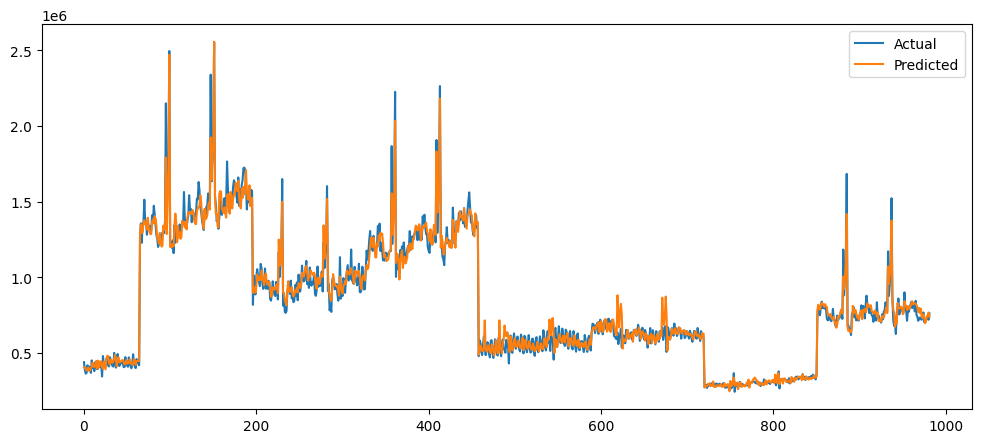

In [12]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.show()

In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
13,rolling_mean_4,0.779134
14,rolling_mean_12,0.115115
10,lag_1,0.068498
8,Week,0.010791
11,lag_4,0.010441
1,Holiday_Flag,0.004016
7,Month,0.003556
15,rolling_std_4,0.002432
12,lag_12,0.001551
6,Year,0.001129
